## 1. Import Libraries

In [14]:
# Load libraries
import os, sys #os dung de doc duong dan file, tao xoa thu muc kiem tra file ton tai,sys lay tham so dong lenh vaf dung thoat chuong trinh
from IPython import display # dung cho viec hien hinh anh
import numpy as np
import matplotlib.pyplot as plt # ve do thi 
import pandas as pd # dung su ly du lieu dang bang doc , loc du lieu tu csv excel
import seaborn as sns # ve bieu do nang cao
import joblib # luu va load mo hinh machine learning
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder # chuyen du lieu thanh vecto ,text thanh so, du lieu thu tu
from sklearn.preprocessing import MinMaxScaler, StandardScaler # chuan hoa du lieu tu 0 ->1,Chuẩn hóa dữ liệu theo mean = 0 và std = 1
from sklearn.model_selection import train_test_split # chia va train/ test
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import warnings
from sklearn.model_selection import cross_val_score
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## 2. Load Dataset

In [15]:
data_path = "eda/data/pima-indians-diabetes.csv"

data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df_dataset = pd.read_csv(data_path, names=data_names)

In [16]:
# shape
print(f'+ Shape : {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape : (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Ngưỡng sinh lý

In [17]:
physiological_ranges = {
    "Pregnancies": (0, 15),
    "Glucose": (35, 250),
    "BloodPressure": (40, 180),
    "SkinThickness": (7, 100),
    "Insulin": (15, 900),
    "BMI": (10, 60),
    "DiabetesPedigreeFunction": (0, 2.5),
    "Age": (21, 90)
}

xóa dữ liệu trùng lập

In [18]:
duplicated = df_dataset.duplicated()

print(f"Số dòng bị trùng: {duplicated.sum()}")

df_clean = df_dataset.drop_duplicates()

print(f"Kích thước sau khi xóa dòng trùng: {df_clean.shape}")

Số dòng bị trùng: 0
Kích thước sau khi xóa dòng trùng: (768, 9)


In [19]:
from xu_ly_du_lieu import xulydulieu

# Áp dụng
df_final = xulydulieu(df_clean,physiological_ranges)

chia dữ liệu 7/3

In [20]:

X = df_final.drop("Outcome", axis=1)
y = df_final["Outcome"]
seed=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (532, 8)
Test size: (229, 8)


In [21]:
# 1. Dữ liệu thô (Raw) - Bạn đã có sẵn
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# 2. Xử lý chuẩn hóa Min/Max
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

# 3. Xử lý chuẩn hóa Standard (Z-score)
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

In [22]:

X_train_sub, X_valid, y_train_sub, y_valid = train_test_split(
    X_train, y_train, test_size=0.3, random_state=seed, stratify=y_train
)

print("Train sub:", X_train_sub.shape)
print("Validation:", X_valid.shape)

Train sub: (372, 8)
Validation: (160, 8)


--- 1. ĐÁNH GIÁ BASELINE (THAM SỐ MẶC ĐỊNH) ---


,Loại dữ liệu,Accuracy (Tập Test)
0,Dữ liệu Thô (Raw),0.720524
1,Chuẩn hóa Min/Max,0.716157
2,Chuẩn hóa Standard,0.733624


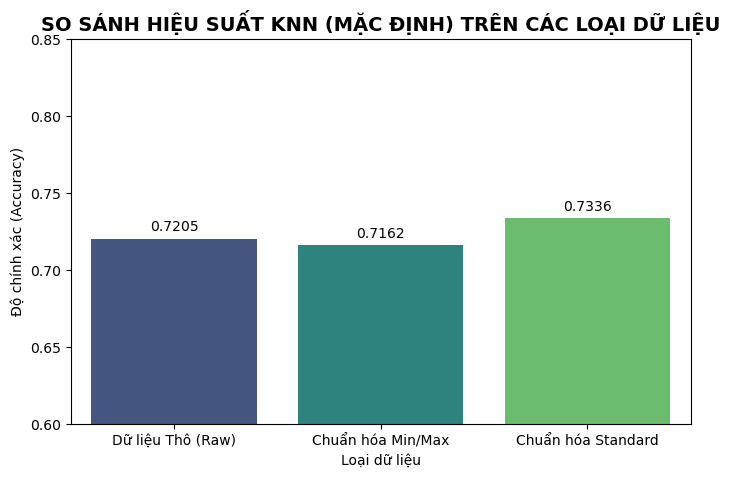

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("--- 1. ĐÁNH GIÁ BASELINE (THAM SỐ MẶC ĐỊNH) ---")
# Khởi tạo mô hình KNN MẶC ĐỊNH (k=5)
knn_baseline = KNeighborsClassifier()

# Chạy trên dữ liệu Thô (Raw)
knn_baseline.fit(X_train_raw, y_train)
acc_raw_knn = accuracy_score(y_test, knn_baseline.predict(X_test_raw))

# Chạy trên dữ liệu Min/Max
knn_baseline.fit(X_train_minmax, y_train)
acc_minmax_knn = accuracy_score(y_test, knn_baseline.predict(X_test_minmax))

# Chạy trên dữ liệu Standard
knn_baseline.fit(X_train_std, y_train)
acc_std_knn = accuracy_score(y_test, knn_baseline.predict(X_test_std))

# Tạo bảng tóm tắt
results_knn = pd.DataFrame({
    'Loại dữ liệu': ['Dữ liệu Thô (Raw)', 'Chuẩn hóa Min/Max', 'Chuẩn hóa Standard'],
    'Accuracy (Tập Test)': [acc_raw_knn, acc_minmax_knn, acc_std_knn]
})

display.display(results_knn)

# Vẽ biểu đồ trình diễn
plt.figure(figsize=(8, 5))
sns.barplot(x='Loại dữ liệu', y='Accuracy (Tập Test)', data=results_knn, palette='viridis')
plt.title('SO SÁNH HIỆU SUẤT KNN (MẶC ĐỊNH) TRÊN CÁC LOẠI DỮ LIỆU', fontsize=14, fontweight='bold')
plt.ylabel('Độ chính xác (Accuracy)')
plt.ylim(0.60, 0.85)
for index, row in results_knn.iterrows():
    plt.text(index, row['Accuracy (Tập Test)'] + 0.005, f"{row['Accuracy (Tập Test)']:.4f}", color='black', ha="center")
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

print("--- 2. TINH CHỈNH THAM SỐ CHO KNN (DÙNG DỮ LIỆU STANDARD) ---")

# 1. Liệt kê các tham số muốn thử
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15], 
    'weights': ['uniform', 'distance'],      
    'metric': ['euclidean', 'manhattan']     
}

# 2. Khởi tạo mô hình và bộ dò tìm 
knn_base = KNeighborsClassifier()
grid_search = GridSearchCV(estimator=knn_base, param_grid=param_grid, cv=10, scoring='accuracy')

# 3. Huấn luyện để dò tìm
grid_search.fit(X_train_std, y_train)

# 4. In ra bộ tham số tốt nhất
best_knn = grid_search.best_estimator_
print("Tham số KNN tốt nhất tìm được:", grid_search.best_params_)

# 5. Đánh giá mô hình đã tinh chỉnh trên tập Test
y_pred_tuned = best_knn.predict(X_test_std)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("Test Accuracy (Sau tinh chỉnh):", acc_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("Ma trận nhầm lẫn:\n", cm_tuned)

--- 2. TINH CHỈNH THAM SỐ CHO KNN (DÙNG DỮ LIỆU STANDARD) ---
Tham số KNN tốt nhất tìm được: {'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'distance'}
Test Accuracy (Sau tinh chỉnh): 0.7336244541484717
Ma trận nhầm lẫn:
 [[124  26]
 [ 35  44]]


K-flod

In [ ]:
import os
import pandas as pd
import joblib
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score

print("--- 3. LƯU KẾT QUẢ VÀO BẢNG TỔNG HỢP ---")

# 1. Tính toán các chỉ số cho KNN
# Lấy điểm validation tốt nhất từ quá trình GridSearchCV
acc_valid = grid_search.best_score_ 
# K-fold test lại lần nữa cho chắc chắn
scores = cross_val_score(best_knn, X_train_std, y_train, cv=10)

# Lấy các chỉ số từ Ma trận nhầm lẫn
tn, fp, fn, tp = cm_tuned.ravel() 
f1 = f1_score(y_test, y_pred_tuned)

# 2. Tạo 1 dòng dữ liệu mới theo format của Bảng tổng hợp
new_row_df = pd.DataFrame({
    "Model": ["K-Neighbors (Tuned)"], 
    "Validation Accuracy": [acc_valid],
    "Test Accuracy": [acc_tuned], # acc_tuned đã tính ở Ô 2
    "Mean Kfold Accuracy": [scores.mean()],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "TN": [tn],
    "F1-score": [f1]
})

# 3. Mở file Excel tổng hợp ra và ghi nối vào
folder_path = "ket_qua"
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

file_path = os.path.join(folder_path, "Bang_Tong_Hop_Models.xlsx") 

if os.path.exists(file_path):
    # Đọc file cũ và nối dòng của KNN vào
    old_df = pd.read_excel(file_path, sheet_name="Summary")
    summary_df = pd.concat([old_df, new_row_df], ignore_index=True)
else:
    summary_df = new_row_df

# Ghi lại vào file Excel
with pd.ExcelWriter(file_path, engine='openpyxl', mode='w') as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)

print("Đã ghi thành công 1 dòng của K-Neighbors vào Bang_Tong_Hop_Models.xlsx")

--- 3. LƯU KẾT QUẢ VÀO BẢNG TỔNG HỢP ---
Đã ghi thành công 1 dòng của K-Neighbors vào Bang_Tong_Hop_Models.xlsx


['knn_tuned_pima.pkl']

In [26]:
!jupyter nbconvert --to html K-neighbors.ipynb

[NbConvertApp] Converting notebook K-neighbors.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 363086 bytes to K-neighbors.html
